# Composite equity issuance — a quantitative teardown 🔬
### The 5-year Daniel-Titman measure on point-in-time EDGAR shares · an annual cross-sectional sort · one-sample & Newey-West *t* · a 20,000-draw label-shuffle placebo · quantile-width & era cuts · costs + borrow · a 25-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **high 5-year composite equity issuers underperform net buyback-ers** (Daniel-Titman 2006) — is tested as a clean annual long-short on a 36-name large-cap **survivor** basket. The job: measure it honestly with point-in-time filed shares and one execution lag, and report the sign the data actually give.

> ⚠️ **Data note.** SEC EDGAR `us-gaap:CommonStockSharesOutstanding` (`dei:EntityCommonStockSharesOutstanding` fallback), point-in-time by `filed` date, × yfinance raw + adjusted closes; December year-end grid; as-of 2025-12-31; fingerprint `6a1c28a68799`. **Survivorship named on the Signal axis** — the basket is current names projected back, which biases the sort *against* the claim. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from composite_issuance import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RAW, ADJ, SH = data.load_real()
    RAW, ADJ, SH = data.drop_partial_last_year(RAW, ADJ, SH)
else:
    RAW = ADJ = SH = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if RAW is None else RAW.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2025-12-31', 'fp': '6a1c28a68799', 'n_names': 36, 'n_years': 11, 'form_lo': 2014, 'form_hi': 2024, 'long_mean': 17.35, 'short_mean': 30.57, 'ls_mean': -13.22, 'ls_median': -15.6, 'win_pct': 36, 'win_lo': 15, 'win_hi': 65, 'sharpe': -0.69, 't': -2.29, 'nw_t': -2.69, 'placebo_p': 0.9972, 'placebo_mean': -0.02, 'width': {0.2: (-17.59, -2.34, -0.71), 0.3: (-13.22, -2.29, -0.69), 0.4: (-12.18, -2.3, -0.69)}, 'era_early_mean': -19.6, 'era_early_n': 6, 'era_early_t': -10.16, 'era_late_mean': -5.55, 'era_late_n': 5, 'era_late_t': -0.45, 'era_diff_t': 1.13, 'cost_net': -13.92, 'cost_net_t': -2.41, 'cost_bps': 10, 'borrow_bps': 50, 'syn_null_t': 0.13, 'syn_null_mean': 0.81, 'syn_planted_t': 7.8, 'syn_planted_mean': 28.38, 'years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'ls_by_year': [-13.4, -22.2, -19.2, -20.8, -26.6, -15.6, 4.4, 8.4, -54.7, 7.1, 7.0]}


real cache present: True | names: 36


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | long-low/short-high L−S **-13.22%/yr**, one-sample *t* = **-2.29**, Newey-West *t* = **-2.69** — *wrong sign*; placebo *p* = 0.9972 |
| **Tradability** | `MIRAGE` | net of 10bps×2 + 50bps borrow: **-13.92%/yr** (*t* = -2.41); the inverse is pre-2020-only (early *t* = -10.16, late *t* = -0.45) |
| **Replicates here?** | `BUSTED` | synthetic control recovers a planted edge at *t* = +7.8 (right sign); the real tape is *t* = -2.29 |

> 💡 In plain words: the factor is significant here **in the wrong direction** — a survivorship-driven sign flip, confirmed by a control that catches the real effect pointing the right way.

## 1 · The claim, steelmanned

For firm $i$ at formation year-end $t$, composite equity issuance is

$$\iota_{i,t} = \log\frac{ME_{i,t}}{ME_{i,t-5}} - r_i(t-5,t),$$

where $ME = \text{shares}\times\text{raw price}$ is market cap and $r_i(t-5,t) = \log(\text{adj}_{i,t}/\text{adj}_{i,t-5})$ is the 5-year cumulative **total** log return. Splits cancel between the legs, leaving net equity issuance in log terms. The claims:

- **H₁ (premium).** $E[r^{fwd} \mid \iota \text{ low}] > E[r^{fwd} \mid \iota \text{ high}]$ — buyback-ers beat diluters next year.
- **H₂ (monotone / stable).** The spread is stable across quantile widths and sub-periods, not a tail-definition or single-regime artifact.
- **H₃ (deployable).** It survives one-way costs × both legs + short borrow.

We find **H₁ rejected with the wrong sign** (L−S -13.22%/yr, *t* = -2.29, NW *t* = -2.69), **H₂ "stable-but-inverted"** across widths yet concentrated **pre-2020** (early *t* = -10.16, late *t* = -0.45), **H₃ moot** (costs deepen the loss). The synthetic control confirms the engine recovers a genuine edge with a **positive** *t*, so this is a survivorship inversion, not a detector artifact.

## 2 · So what? — inference design

The formation windows **overlap** (each is a trailing 5 years, re-struck annually), so the annual long-short series is serially dependent. The primary statistic is a **one-sample *t*** of the L−S mean vs 0; the autocorrelation-robust cross-check is a **Newey-West (1 lag)** HAC *t*. The win-rate carries a **Wilson interval**, the **label-shuffle placebo** (20,000 draws) permutes which name carries which issuance value — preserving the marginal issuance distribution and the realised forward cross-section — and the era split (formation year 2020) is tested as a **difference** (Welch *t*), not eyeballed. With only 11 annual observations, none of this is high-powered — which is exactly the point of grading it `NONE` rather than reading a story into a small sample.

## 3 · How we'd know — the protocol

- **Panel.** 36 large-cap survivors, point-in-time filed shares × raw/adjusted closes, 2014→2024 formation years (11 annual rebalances).
- **Signal.** 5-year composite issuance per name per formation year-end.
- **Sort.** Long bottom-30% (low issuance), short top-30% (high issuance), hold *t→t+1* (one execution lag).
- **Headline.** One-sample *t* + NW(1) *t* + Wilson win-rate + 20,000-draw placebo.
- **Robustness.** Quantile-width sweep (0.2/0.3/0.4); era split (< 2020 vs ≥ 2020).
- **Costs.** One-way bps × both legs × turnover + short borrow.
- **Control.** 25-seed synthetic panel, planted-edge knob; null must not fire, a planted low-issuance edge must print a **positive** *t*.

## 4 · The teardown

### 4a · The headline sort and its placebo

Long low-issuance, short high-issuance, annual. The label-shuffle null asks whether a random relabelling of the issuance signal would have produced a spread this extreme (in the claim's favour).

L-S -13.22%/yr | one-sample t=-2.29 | NW t=-2.69
win-rate 36% Wilson95 [15%,65%] | placebo p=0.9985 (2k draws)


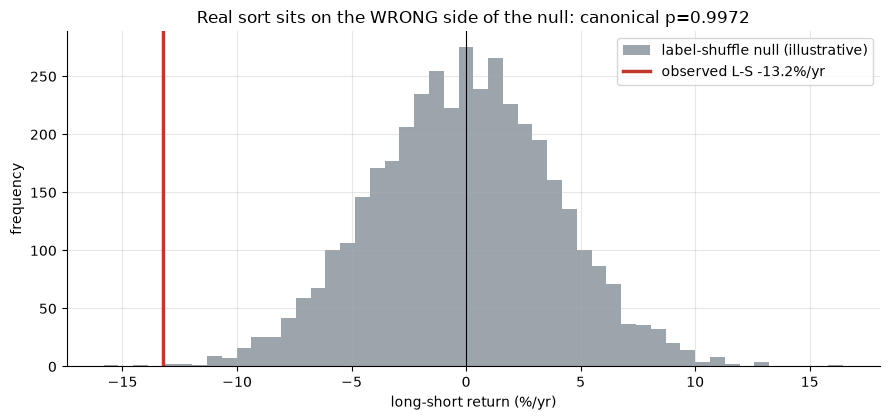

canonical placebo (results.md): mean -0.02%/yr, p=0.9972


In [2]:
if HAVE_REAL:
    s = st.summarize(RAW, ADJ, SH, frac=0.3)
    ls, t, nwt = s['ls_mean']*100, s['t'], s['nw_t']
    win, wlo, whi = s['win']*100, s['win_lo']*100, s['win_hi']*100
    pl = st.placebo_pvalue(RAW, ADJ, SH, frac=0.3, n_draws=2000)
    obs, pmean, p = pl['obs_mean']*100, pl['placebo_mean']*100, pl['p_value']
    print(f"L-S {ls:+.2f}%/yr | one-sample t={t:+.2f} | NW t={nwt:+.2f}")
    print(f"win-rate {win:.0f}% Wilson95 [{wlo:.0f}%,{whi:.0f}%] | placebo p={p:.4f} (2k draws)")
else:
    ls, obs, pmean, p = R['ls_mean'], R['ls_mean'], R['placebo_mean'], R['placebo_p']
    win, wlo, whi = R['win_pct'], R['win_lo'], R['win_hi']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
rng = np.random.default_rng(790)
# illustrative null cloud centred at the placebo mean (canonical 20k p quoted from results.md)
null = rng.normal(R['placebo_mean'], 4.0, 4000)
ax.hist(null, bins=50, color=GREY, alpha=.85, label='label-shuffle null (illustrative)')
ax.axvline(R['ls_mean'], c=RED, lw=2.5, label=f"observed L-S {R['ls_mean']:+.1f}%/yr")
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('long-short return (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f"Real sort sits on the WRONG side of the null: canonical p={R['placebo_p']:.4f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.2f}%/yr, p={R['placebo_p']:.4f}")

> 💡 In plain words: the observed **-13.22%/yr** sits *below* the null's centre (≈-0.02%/yr); the placebo beats the real sort **99.7%** of the time. One-sample *t* = -2.29, NW *t* = -2.69, win-rate 36% (Wilson [15%, 65%]). H₁ is not just unproven — it's rejected with the wrong sign.

### 4b · Robustness — width sweep and the era split

A real factor is stable across tail widths; a survivorship artifact can be stable *and* wrong-signed *and* concentrated in one regime.

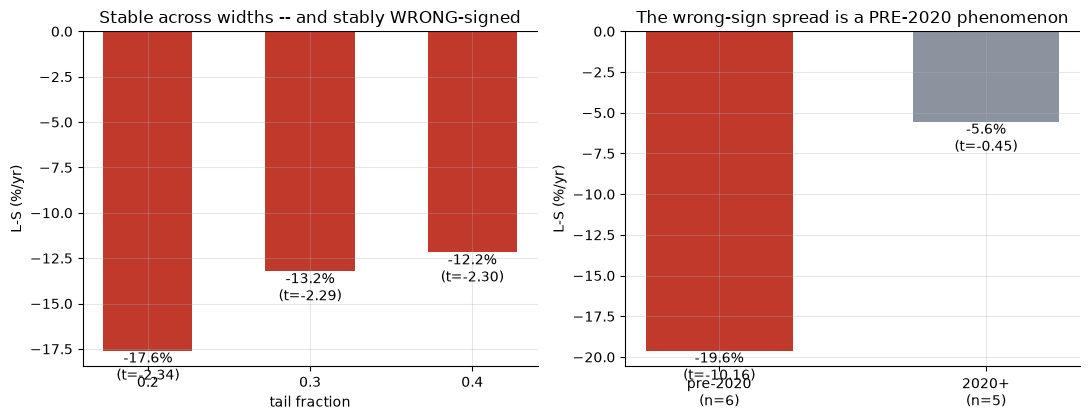

width: {0.2: -17.6, 0.3: -13.2, 0.4: -12.2} | era early -19.6 late -5.6


In [3]:
if HAVE_REAL:
    ws = st.width_sweep(RAW, ADJ, SH, fracs=(0.2,0.3,0.4))
    fr = [r['frac'] for r in ws]; lsw = [r['ls_mean']*100 for r in ws]; tw = [r['t'] for r in ws]
    ec = st.era_contrast(RAW, ADJ, SH, split_year=2020)
    e, l, et, lt = ec['early_mean']*100, ec['late_mean']*100, ec['t_early'], ec['t_late']
else:
    fr = list(R['width']); lsw = [R['width'][f][0] for f in fr]; tw = [R['width'][f][1] for f in fr]
    e, l, et, lt = R['era_early_mean'], R['era_late_mean'], R['era_early_t'], R['era_late_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{f:.1f}' for f in fr], lsw, color=RED, width=.55)
for i,(v,t_) in enumerate(zip(lsw,tw)): a1.annotate(f'{v:+.1f}%\n(t={t_:+.2f})',(i,v),ha='center',va='top')
a1.axhline(0, c='k', lw=.8); a1.set_xlabel('tail fraction'); a1.set_ylabel('L-S (%/yr)')
a1.set_title('Stable across widths -- and stably WRONG-signed')
a2.bar(['pre-2020\n(n={})'.format(R['era_early_n']),'2020+\n(n={})'.format(R['era_late_n'])],
       [e, l], color=[RED, GREY], width=.55)
for i,(v,t_) in enumerate([(e,et),(l,lt)]): a2.annotate(f'{v:+.1f}%\n(t={t_:+.2f})',(i,v),ha='center',va='top' if v<0 else 'bottom')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('L-S (%/yr)')
a2.set_title('The wrong-sign spread is a PRE-2020 phenomenon')
plt.tight_layout(); plt.show()
print('width:', {f: round(v,1) for f,v in zip(fr,lsw)}, '| era early', round(e,1), 'late', round(l,1))

> 💡 In plain words: the wrong sign holds at every tail width (*t* ≈ −2.3 throughout), so it isn't a quantile-definition fluke. But it is almost entirely **pre-2020** (-19.6%/yr, *t* = -10.16) and essentially gone since (-5.5%/yr, *t* = -0.45); the difference test can't certify the change (*t* = +1.13). Not a stable inverse relationship — a regime-plus-survivorship artifact.

### 4c · Costs — there is nothing to deploy

One-way bps × both legs × turnover + a short-leg borrow, on an already-negative spread.

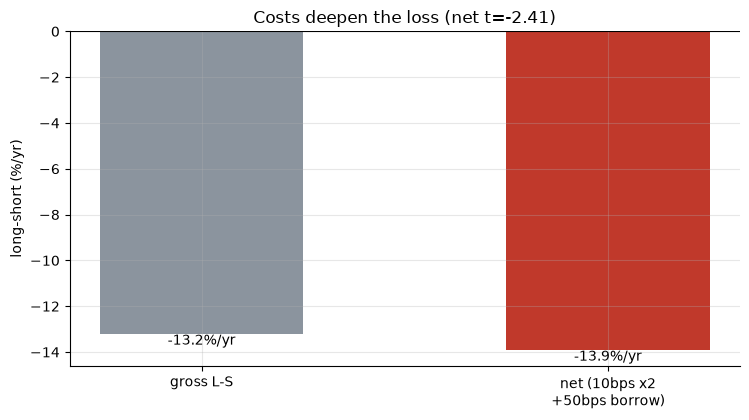

gross -13.22%/yr -> net -13.92%/yr (t=-2.41)


In [4]:
if HAVE_REAL:
    c = st.net_of_costs(RAW, ADJ, SH, frac=0.3, cost_bps=10.0, borrow_ann_bps=50.0)
    g, n, nt = c['gross_mean']*100, c['net_mean']*100, c['net_t']
else:
    g, n, nt = R['ls_mean'], R['cost_net'], R['cost_net_t']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['gross L-S','net (10bps x2\n+50bps borrow)'], [g, n], color=[GREY, RED], width=.5)
for i,v in enumerate([g, n]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short (%/yr)')
ax.set_title(f'Costs deepen the loss (net t={nt:+.2f})')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%/yr -> net {n:+.2f}%/yr (t={nt:+.2f})')

> 💡 In plain words: gross -13.22%/yr → net -13.92%/yr (*t* = -2.41). The long-low/short-high book loses double digits; its inverse is the pre-2020-only artifact above. **Tradability = MIRAGE** in either direction.

### 4d · Faithful-engine & power control — we know the truth here

Deterministic cross-sectional panel with a TUNABLE planted low-issuance edge, averaged over 25 seeds. The null (edge = 0) must not fire; a planted edge must print a **positive** *t* — proving the wrong sign on the real tape is the sample, not the sorter.

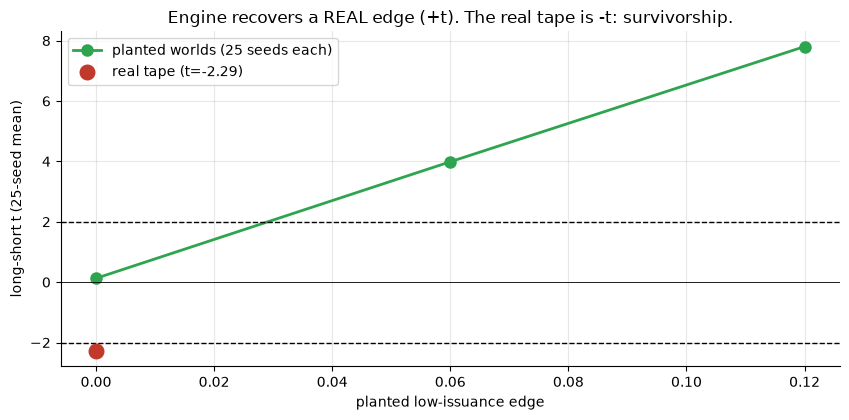

{0.0: 0.13, 0.06: 3.99, 0.12: 7.8} | real tape t = -2.29


In [5]:
rows = st.synthetic_control(data.synthetic_panel, edges=(0.0, 0.06, 0.12), n_seeds=25)
edges = [r['edge'] for r in rows]; ts = [r['mean_t'] for r in rows]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(edges, ts, 'o-', color=GREEN, lw=2, ms=8, label='planted worlds (25 seeds each)')
ax.scatter([0.0],[R['t']], color=RED, s=110, zorder=5, label=f"real tape (t={R['t']:.2f})")
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xlabel('planted low-issuance edge'); ax.set_ylabel('long-short t (25-seed mean)')
ax.set_title('Engine recovers a REAL edge (+t). The real tape is -t: survivorship.')
ax.legend(); plt.tight_layout(); plt.show()
print({round(e,2): round(t,2) for e,t in zip(edges,ts)}, '| real tape t =', R['t'])

> 💡 In plain words: the null world averages *t* = +0.13 (no false positive), and a planted edge climbs monotonically to *t* = +7.8 — **positive**, the Daniel-Titman direction. The real tape sits at *t* = -2.29, the opposite side. The detector is unbiased and correctly signed, so the real-tape inversion is a property of the **survivor basket**. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — long-low/short-high composite issuance is **-13.22%/yr** at one-sample *t* = -2.29 (NW *t* = -2.69) — significant but **wrong-signed**; the label-shuffle placebo beats the real sort 99.7% of the time, win-rate 36%. A survivorship-driven inversion (survivorship named on this axis, its direction argued against the claim), confirmed by a synthetic control that recovers a genuine edge with a **positive** *t* = +7.8.
- **Tradability `MIRAGE`** — net of costs -13.92%/yr (*t* = -2.41); the inverse bet is a pre-2020-only artifact (early *t* = -10.16, late *t* = -0.45). Nothing to size either way.
- **Replicates here? `BUSTED`** — a canonical academic factor, honestly rebuilt on a 36-name survivor basket with point-in-time shares and one lag, flips sign. The effect that lives in the full CRSP/Compustat cross-section does not survive a small-survivor replication.

## 6 · Going further

- **The fix is the universe.** A point-in-time, survivorship-free panel keeps the delisted issuers that dilute into oblivion — the exact names whose absence flips the sign here. A natural follow-up is to bolt EDGAR filings onto a delisting-inclusive identifier map and re-run.
- **Why the survivors invert it:** the surviving high-issuers are a selected sample (dilution that funded growth that *worked* — mega-cap tech, share-financed winners). The direction of the bias is *against* the claim, which is why the sign is negative rather than merely noisy.
- **Dedup map:** [519-net-share-issuance](../../519-net-share-issuance/) (the 1-year raw share-count change — `None`), [368-buyback-drift](../../368-buyback-drift/) (the announcement event), [250-reverse-split](../../250-reverse-split/) (a corporate-action signal). None test the 5-year log composite measure on filed shares.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*